# Localizing Causal Variables: Population-Level Activation Patching

In notebook 02, we traced a single (base, counterfactual) pair: patching each (layer, token_position) cell and observing which cells carry the distinguishing signal. That gave intuition for *one* input. Now we scale up.

**Activation patching at population scale** asks: across *many* base/counterfactual pairs, which (layer, token_position) cell most reliably encodes a causal variable?

The metric is **Interchange Intervention Accuracy (IIA)**: the fraction of interventions where patching at a given cell causes the model's output to agree with the causal model's prediction. A cell with IIA near 1.0 reliably encodes the variable; chance level for 3-way MCQA is about 0.33.

In this notebook we:
1. Use named token positions defined by the MCQA task (not just raw indices) to scan a meaningful subset of cells
2. Run centroid-mode localization over a small demo dataset to understand the mechanics
3. Scale to the full dataset using the `locate` runner and inspect the resulting heatmaps

In [1]:
# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1

from causalab.neural.pipeline import LMPipeline
from causalab.tasks.MCQA.causal_models import positional_causal_model
from causalab.tasks.MCQA.counterfactuals import sample_answerable_question
import torch
import random

causal_model = positional_causal_model

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)
print("DEVICE:", pipeline.model.device)


def checker(neural_output, causal_output):
    return (
        causal_output.strip() in neural_output["string"].strip()
        or neural_output["string"].strip() in causal_output.strip()
    )

`torch_dtype` is deprecated! Use `dtype` instead!
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


DEVICE: cuda:0


## Named Token Positions

In notebook 02 we patched every token position using `get_list_of_each_token`. That gave a dense trace for one pair. For population-scale experiments, we use named positions defined by the task:

- `correct_symbol` — the token showing the correct answer label (position varies based on which choice is correct)
- `correct_symbol_period`, `symbol0`, `symbol0_period`, `symbol1`, `symbol1_period` — related structural positions
- `last_token` — the `:` after `Answer`, where the model outputs its prediction

Using named positions instead of absolute indices allows the experiment to generalize across inputs with different lengths — the correct symbol may appear at different absolute positions depending on the question wording, but the named position resolves correctly every time.

The `create_token_positions` function returns a dict keyed by position name. Each value is a `TokenPosition` object that knows how to locate itself within any prompt from this task.

In [2]:
from causalab.tasks.MCQA.token_positions import create_token_positions

all_token_positions = create_token_positions(pipeline)

ordered_position_names = [
    "correct_symbol",
    "correct_symbol_period",
    "symbol0",
    "symbol0_period",
    "symbol1",
    "symbol1_period",
    "last_token",
]
token_positions = [all_token_positions[name] for name in ordered_position_names]

print(f"Defined {len(token_positions)} named token positions:")

# Sample one pair to show which token each position selects
while True:
    original = sample_answerable_question()
    orig_pred = pipeline.generate([original]).strings[0]
    if checker({"string": orig_pred}, original["raw_output"]):
        break

print(f"\nExample prompt: {original['raw_input'].strip()}\n")
for tp in token_positions:
    print(f"{tp.id}:")
    print(f"  {tp.highlight_selected_token(original)[:80]}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Defined 7 named token positions:

Example prompt: The car is brown. What color is the car?
J. red
R. brown
Answer:

correct_symbol:
  <|begin_of_text|>The car is brown. What color is the car?
J. red
**R**. brown
An
correct_symbol_period:
  <|begin_of_text|>The car is brown. What color is the car?
J. red
R**.** brown
An
symbol0:
  <|begin_of_text|>The car is brown. What color is the car?
**J**. red
R. brown
An
symbol0_period:
  <|begin_of_text|>The car is brown. What color is the car?
J**.** red
R. brown
An
symbol1:
  <|begin_of_text|>The car is brown. What color is the car?
J. red
**R**. brown
An
symbol1_period:
  <|begin_of_text|>The car is brown. What color is the car?
J. red
R**.** brown
An
last_token:
  <|begin_of_text|>The car is brown. What color is the car?
J. red
R. brown
Answer


## Patching at Population Scale

To localize a variable across a population of inputs, we:

1. Collect multiple base/counterfactual pairs where the variable differs
2. Build a (layer × token_position) grid of intervention **targets** using `build_residual_stream_targets`
3. Score each target using **centroid mode**: for each cell, measure how often the patched output's argmax token matches the per-class reference centroid's argmax. Higher accuracy = better localization.

Centroid mode works by:
- Computing a reference output distribution per class (by running the model on class-typical inputs)
- For each (layer, position) cell, collecting patched activations and measuring how often the patched output agrees with the correct class reference
- A cell with score near 1.0 means patching there reliably moves the model's output toward the correct class — it encodes the variable

**Why centroid (not pairwise)?** The MCQA task uses `resample_variable: all`, which generates counterfactuals that change multiple variables simultaneously. Pairwise mode would only see correct-vs-incorrect outputs and would only find the last-token position (where the output is written). Centroid mode compares to per-class reference distributions and correctly scores all positions.

In [3]:
# PARAMETERS
LAYERS = [0, 4, 8, 12, 15]   # subset of layers for the demo (None = all)
N_PAIRS = 8                   # number of base/counterfactual pairs to collect
N_STEER = 4                   # centroid steer examples per class (keep small for demo speed)

from causalab.neural.activations import build_residual_stream_targets

# Collect N_PAIRS base/counterfactual pairs
from causalab.causal.counterfactual_dataset import CounterfactualExample

dataset: list[CounterfactualExample] = []
while len(dataset) < N_PAIRS:
    orig = sample_answerable_question()
    cf_inputs = {var: orig[var] for var in causal_model.inputs}
    answer_symbol_key = f"symbol{orig['answer_position']}"
    new_symbols = list({"A", "B", "C"}.difference({orig[answer_symbol_key]}))
    cf_inputs[answer_symbol_key] = random.choice(new_symbols)
    cf = causal_model.new_trace(cf_inputs)

    orig_pred = pipeline.generate([orig]).strings[0]
    cf_pred = pipeline.generate([cf]).strings[0]

    if checker({"string": orig_pred}, orig["raw_output"]) and checker({"string": cf_pred}, cf["raw_output"]):
        dataset.append({"input": orig, "counterfactual_inputs": [cf]})

print(f"Collected {len(dataset)} base/counterfactual pairs")

# Build a (layer × token_position) grid of interchange targets
targets = build_residual_stream_targets(
    pipeline=pipeline,
    layers=LAYERS,
    token_positions=token_positions,
    mode="one_target_per_unit",
)
print(f"Built {len(targets)} targets ({len(LAYERS)} layers × {len(token_positions)} positions)")

Collected 8 base/counterfactual pairs
Built 35 targets (5 layers × 7 positions)


## Running the Centroid Scan

We run `run_centroid_layer_scan` — the same function `locate/main.py` uses internally. It needs:

- `score_token_ids`: the vocabulary token IDs for the output symbols (A, B, C). This tells the scorer which tokens to watch.
- `n_classes`: how many output classes there are (3 for MCQA)
- `example_to_class`: a function that maps each example to its class index
- `ref_dists`: per-class reference distributions (computed from a clean forward pass over class-representative inputs)

The scanner will steer `n_steer` examples per class to build the centroids, then score every target cell.

In [4]:
from causalab.methods.interchange.layer_scan import run_centroid_layer_scan
from causalab.methods.metric import compute_reference_distributions
from causalab.runner.helpers import resolve_task, get_output_token_ids, _argmax_accuracy
from omegaconf import OmegaConf

# Resolve the MCQA task with target_variable="answer" (the letter symbol, e.g. "E" or "S").
# Using "answer_position" (integers 0, 1) would be wrong here: position integers tokenize
# as multi-token sequences [" 0"] = [space, "0"] that share a common first token, so
# class_probabilities can't distinguish the two classes and accuracy collapses to chance.
# "answer" gives 26 single-token classes (one per alphabet letter); only the ~2 letters
# actually present in the demo dataset contribute to the centroid scan.
task, _ = resolve_task(
    task_name="MCQA",
    task_config={"enumerate_all": False, "resample_variable": "all"},
    target_variable="answer",
    seed=42,
)
score_token_ids, _ = get_output_token_ids(task, pipeline)
n_classes = len(task.intervention_values)

# Find which classes (answer letters) are actually present in the demo dataset
present_classes = sorted({task.intervention_value_index(ex) for ex in dataset})
present_letters = [task.intervention_values[i] for i in present_classes]
print(f"Total output classes: {n_classes} (all alphabet letters)")
print(f"Classes present in demo dataset: {present_letters} ({len(present_letters)} classes)")
print(f"Score token IDs (first 3 shown): {score_token_ids[:3]} ...")

# Compute per-class reference distributions (clean forward passes)
ref_dists_raw = compute_reference_distributions(
    dataset=dataset,
    score_token_ids=score_token_ids,
    n_classes=n_classes,
    example_to_class=task.intervention_value_index,
    pipeline=pipeline,
    batch_size=4,
    score_token_index=0,
    full_vocab_softmax=True,
)
ref_dists = ref_dists_raw / ref_dists_raw.sum(dim=-1, keepdim=True).clamp(min=1e-10)
print(f"Reference distributions shape: {ref_dists.shape}  (n_classes × n_score_tokens)")
print(f"  (only classes {present_letters} are populated from data; others get uniform)")

# Run the centroid scan over all targets
print("\nRunning centroid layer scan...")
scores = run_centroid_layer_scan(
    interchange_targets=targets,
    dataset=dataset,
    pipeline=pipeline,
    batch_size=4,
    score_token_ids=score_token_ids,
    n_classes=n_classes,
    example_to_class=task.intervention_value_index,
    ref_dists=ref_dists,
    score_token_index=0,
    n_steer=N_STEER,
    comparison_fn=_argmax_accuracy,
)
print(f"\nScores computed for {len(scores)} cells")
print("Top 5 cells (highest accuracy = best localization):")
sorted_cells = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
for (layer, pos_id), score in sorted_cells:
    print(f"  Layer {layer:2d}, {pos_id:30s}: {score:.4f}")

Total output classes: 26 (all alphabet letters)
Classes present in demo dataset: ['D', 'E', 'J', 'N', 'P', 'Y', 'Z'] (7 classes)
Score token IDs (first 3 shown): [[362], [426], [356]] ...
Reference distributions shape: torch.Size([26, 26])  (n_classes × n_score_tokens)
  (only classes ['D', 'E', 'J', 'N', 'P', 'Y', 'Z'] are populated from data; others get uniform)

Running centroid layer scan...


Centroid layer scan: 100%|██████████| 35/35 [00:09<00:00,  3.70it/s]


Scores computed for 35 cells
Top 5 cells (highest accuracy = best localization):
  Layer  0, correct_symbol                : 1.0000
  Layer 15, last_token                    : 1.0000
  Layer  8, correct_symbol                : 0.9286
  Layer  4, correct_symbol                : 0.8571
  Layer  0, symbol1                       : 0.5714


## Visualizing Localization

We render the scores as a (layer × position) heatmap. Each cell shows the centroid-mode accuracy. For centroid mode, **higher scores indicate better localization** — high accuracy means patching at that cell reliably moves the output toward the correct class reference.

Look for:
- **A localized bright region**: one or a few cells stand out with much higher scores than the rest. That cluster is where the variable is encoded.
- **Embedding layer (if included)**: the signal should be strongest at the token carrying the answer symbol, because those tokens are exactly where the two prompts diverge.
- **Final layers, last_token position**: the signal should also be strong there — that is where the model reads out the prediction.
- **Middle layers**: watch for the signal moving from the input position (correct_symbol) toward the output position (last_token) across layers.

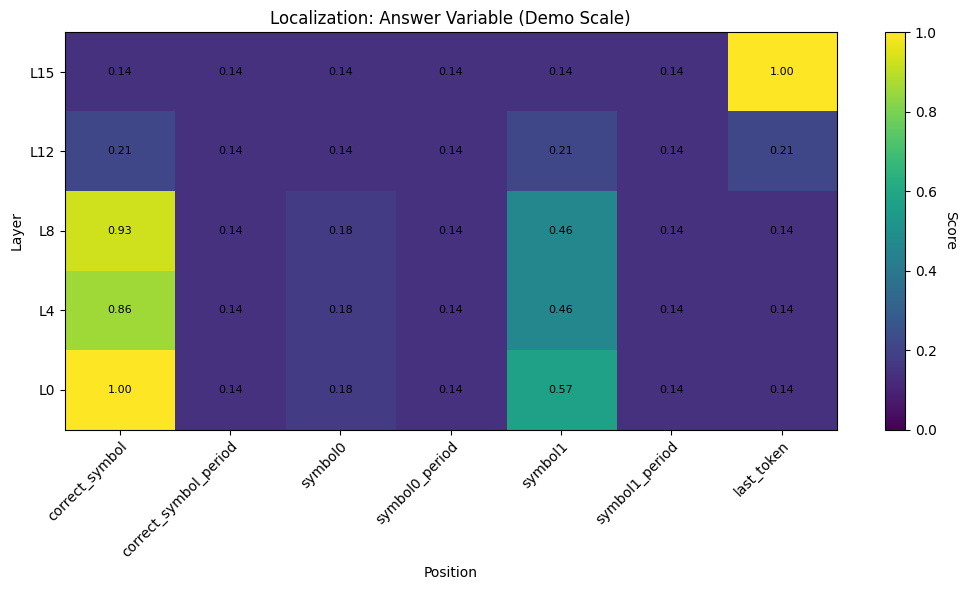

Best localization cell: Layer 0, Position correct_symbol
Accuracy (IIA): 1.0000  (higher = more localized)


In [ ]:
from causalab.io.plots.score_heatmap import plot_residual_stream_heatmap

token_position_ids = [tp.id for tp in token_positions]
best_cell = max(scores, key=scores.get)

plot_residual_stream_heatmap(
    scores=scores,
    layers=LAYERS,
    token_position_ids=token_position_ids,
    title="Localization: Answer Variable",
    figure_format="png",
)

print(f"Best localization cell: Layer {best_cell[0]}, Position {best_cell[1]}")
print(f"Accuracy (IIA): {scores[best_cell]:.4f}  (higher = more localized)")

## What to Look For

**A well-localized result** shows one or a few adjacent cells with much higher accuracy than the rest of the grid. The `correct_symbol` position at the embedding layer is expected to have a high score — those tokens are exactly where the two prompts differ. In later layers, the signal should move to the `last_token` position as the model routes the answer to the output site.

**If scores are uniform** across all cells (and near chance, ≈ 1/n_classes): the demo dataset is too small (8 pairs) for stable centroid estimation. The `locate` runner in Section 2 uses 100+ pairs to get reliable scores.

**If scores are uniformly high everywhere**: the counterfactual design may not distinguish the target variable — for example, `resample_variable: all` changes many variables at once, which is why centroid mode is needed (it handles multi-variable resampling correctly; pairwise would not).

Try re-running with:
- More layers: change `LAYERS = [0, 4, 8, 12, 15]` to include all layers (`LAYERS = list(range(16))`)
- A larger dataset: change `N_PAIRS` to 20 or 30 (slower but more stable scores)
- More steer examples: change `N_STEER` to 8 or 16

---

## From exploration to analysis

The localization above answers a question about a *small demo dataset* of 8 pairs across 5 layers. A research question lives at the level of populations: **across all MCQA inputs, which (layer, token_position) cell most reliably encodes each causal variable?** Answering that requires:

- Collecting 100+ carefully designed base/counterfactual pairs (not just random samples)
- Scanning all hidden layers (not just a sample)
- Aggregating scores over many examples to reduce noise
- Saving artifacts for downstream analyses (`subspace`, `activation_manifold`)
- Running with versioned, reproducible hyperparameters

This is exactly what the **`locate` analysis** does. Under the hood it calls the same `run_centroid_layer_scan` and `plot_residual_stream_heatmap` you just wrote — packaged behind a Hydra config that becomes the single source of truth for every parameter. The rest of this notebook shows how to configure `locate` end-to-end.

## Running `locate` end-to-end

The config below is a complete runner preset for the `locate` analysis. Edit any field and re-run the cell to update the config file. The table below maps config fields to the `PARAMETERS` you set in Section 1.

| Field | What it controls |
|---|---|
| `method` | `interchange` (activation patching like Section 1) or `dbm_binary` (learned binary masks) |
| `mode` | `centroid` scores each cell by Interchange Intervention Accuracy (IIA) against per-class reference centroids; `pairwise` checks whether patching causes the exact output token to match the counterfactual |
| `layers` | Which layers to scan; `null` scans all hidden layers (0 to num_layers−1) |
| `n_steer` | Number of examples per class used to compute class centroids (centroid mode only); corresponds to `N_STEER` above |
| `enumerate_all` | Set to `true` to use every possible MCQA input (deterministic and exhaustive); `false` uses random sampling |
| `figure_format` | `png` for notebook display, `pdf` for publication-quality saved figures |

In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: MCQA
  - /model: llama32_1b_instruct
  - /analysis/locate
  - _self_
task:
  enumerate_all: true  # use all possible MCQA inputs (deterministic)
  target_variable: answer

locate:
  method: interchange
  mode: centroid      # centroid is correct with resample_variable: all (docs/CODEBASE.md §7)
  layers: null        # null = scan all hidden layers
  n_steer: 32
  visualization:
    figure_format: png
"""

In [7]:
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "localize_with_patching_demo")
print(f"Written to {path}\n")

cfg = load_runner_config("localize_with_patching_demo")
print("Full hydra config (with all defaults resolved):")
print(OmegaConf.to_yaml(cfg))

Written to causalab/configs/localize_with_patching_demo.yaml

Full hydra config (with all defaults resolved):
seed: 42
experiment_root: artifacts/${task.name}/${model.id}
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variable: answer
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interchange
  batch_size: 32
  layers: null
  token_positions: null
  component: residual_stream
  mode: centroid
  n_steer: 32
  source_model: null
  visualization:
    figure_format: png
    single_pair_trace: true



Verify the resolved config before running: `resample_variable: all` should be present (confirming that `mode: centroid` is the correct pairing), and no field should show `???` (which would indicate an unresolved Hydra interpolation).

In [8]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "localize_with_patching_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-04-27 15:28:57,785][__main__][INFO] - === Step: locate (locate) ===
[2026-04-27 15:29:06,893][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.2-1B-Instruct (device=cuda)


`torch_dtype` is deprecated! Use `dtype` instead!
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-04-27 15:29:07,937][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'
[2026-04-27 15:29:08,479][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['answer']
[2026-04-27 15:29:08,480][causalab.analyses.locate.main][INFO] - === Locate: target_variable=answer ===
[2026-04-27 15:29:08,719][causalab.runner.helpers][INFO] - Deduplicated train: 1000 -> 999 unique prompts
[2026-04-27 15:29:08,731][causalab.runner.helpers][INFO] - Dataset: 999 train, 50 test
[2026-04-27 15:29:08,734][causalab.analyses.locate.run_interchange][WARNING] - No baseline accuracy found at artifacts/MCQA/llama32_1b_instruct/baseline/accuracy.json
[2026-04-27 15:29:08,734][causalab.analyses.locate.run_interchange][WARNING] - No baseline ref_dists found at 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[2026-04-27 15:29:09,556][causalab.methods.metric][INFO] - Base model accuracy: 49/50 (98.0%)
[2026-04-27 15:29:09,556][causalab.methods.metric][INFO] - Base model prob accuracy: 74.9%


Centroid layer scan: 100%|██████████| 112/112 [02:07<00:00,  1.14s/it]


Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol/patched_dim0.png
[2026-04-27 15:31:23,456][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol/patched_dim0.png
Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol_period/patched_dim0.png
[2026-04-27 15:31:23,797][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol_period/patched_dim0.png
Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Psymbol0/patched_dim0.png
[2026-04-27 15:31:24,116][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Psymbol0/patched_dim0.png
Saved figure to artifa

## Artifacts

All outputs land in `artifacts/{task}/{model}/locate/{method}/`.

In [9]:
artifact_dir = os.path.join(
    project_root,
    cfg.experiment_root,
    "locate",
    cfg.locate.method,
)
print(f"Artifact directory: {artifact_dir}\n")
print("Top-level contents:")
for item in sorted(os.listdir(artifact_dir)):
    item_path = os.path.join(artifact_dir, item)
    if os.path.isdir(item_path):
        print(f"  [DIR]  {item}")
    else:
        size = os.path.getsize(item_path)
        print(f"  [FILE] {item} ({size} bytes)")

Artifact directory: artifacts/MCQA/llama32_1b_instruct/locate/interchange

Top-level contents:
  [DIR]  answer
  [FILE] metadata.json (710 bytes)
  [FILE] results.json (5783 bytes)
  [FILE] single_pair_trace.json (18422 bytes)
  [FILE] single_pair_trace_heatmap.png (68359 bytes)


### Single-pair trace

The `single_pair_trace.json` artifact is the same structure you'd build in notebook 02 — now saved to disk by the analysis. It records the per-cell output strings from one carefully selected (base, counterfactual) pair. Loading it and calling `plot_single_pair_trace_heatmap` is identical to what you did in notebook 02.

Base:           The ball is purple. What color is the ball?
E. purple
X. yellow
Answer:
Counterfactual: The ball is purple. What color is the ball?
D. purple
W. yellow
Answer:



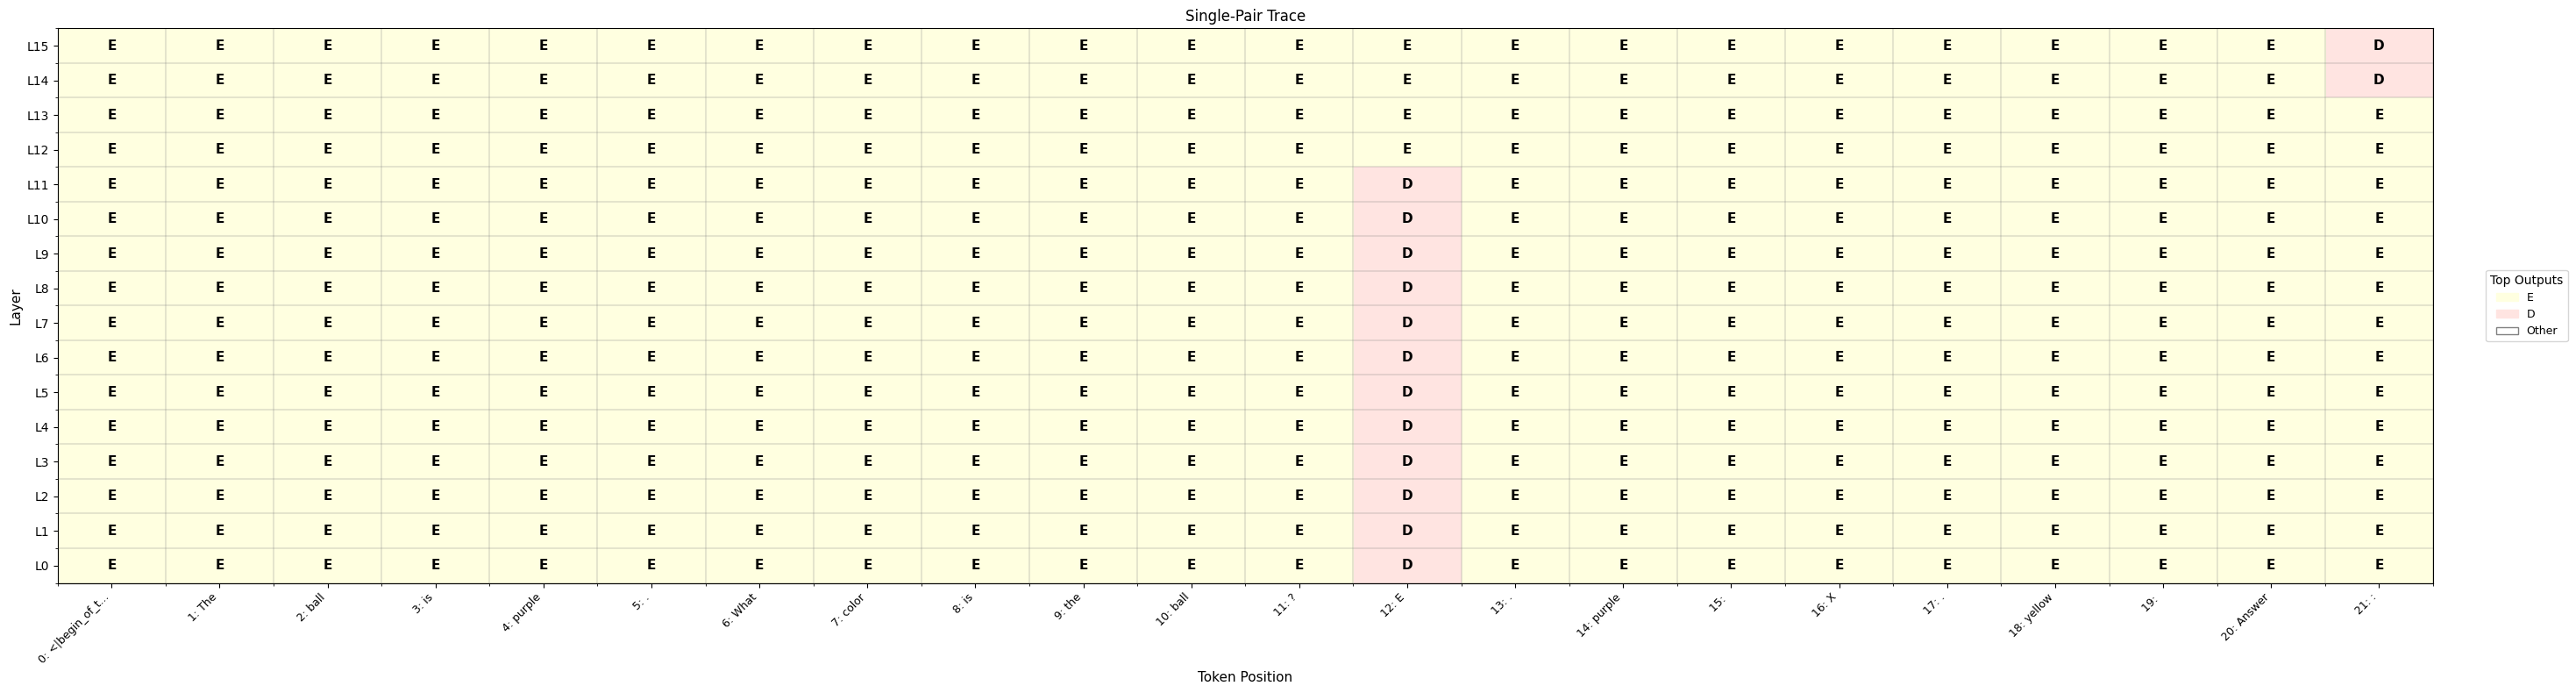

In [10]:
import json
from causalab.io.plots.string_heatmap import plot_single_pair_trace_heatmap

trace_path = os.path.join(artifact_dir, "single_pair_trace.json")
if os.path.exists(trace_path):
    with open(trace_path) as f:
        saved_trace_data = json.load(f)

    print(f"Base:           {saved_trace_data['prompt']}")
    print(f"Counterfactual: {saved_trace_data['counterfactual_prompt']}")
    print()

    plot_single_pair_trace_heatmap(saved_trace_data, figure_format="png")
else:
    print("Note: single_pair_trace.json not found (visualization disabled in config?)")

### Variable heatmaps

The score heatmaps aggregate over the full dataset. Each cell shows the centroid-mode accuracy: the fraction of patches whose argmax output token matches the per-class reference centroid's argmax.

For centroid mode: **higher score = better localization** (high accuracy means patching at that cell reliably moves the output toward the correct class). The brightest cell in the heatmap is the best (layer, position) candidate for encoding the variable.

The `locate` analysis loops over target variables and produces one heatmap per variable. Each variable's `results.json` records its `best_cell` — the input that downstream analyses (`subspace`, `activation_manifold`) auto-resolve when no explicit layer is specified.


--- answer ---


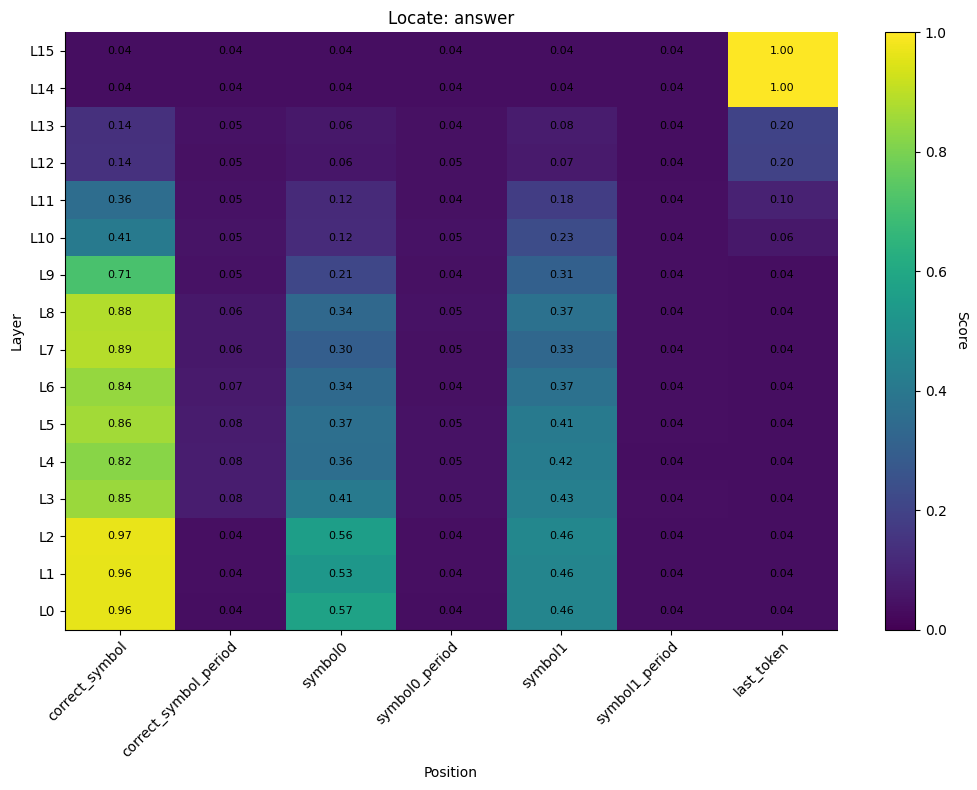

Best cell: Layer 14, Position last_token, Accuracy: 1.0000


In [11]:
from glob import glob
from IPython.display import Image, display

for var_name in sorted(os.listdir(artifact_dir)):
    var_dir = os.path.join(artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue

    heatmap_paths = glob(os.path.join(var_dir, "heatmap.*"))
    if heatmap_paths:
        print(f"\n--- {var_name} ---")
        display(Image(filename=heatmap_paths[0]))

        results_path = os.path.join(var_dir, "results.json")
        if os.path.exists(results_path):
            with open(results_path) as f:
                results = json.load(f)
            best_cell = results.get("best_cell")
            if best_cell:
                key = f"{best_cell['layer']}|{best_cell['token_position']}"
                score = results["scores_per_cell"].get(key, "?")
                print(
                    f"Best cell: Layer {best_cell['layer']}, "
                    f"Position {best_cell['token_position']}, "
                    f"Accuracy: {score:.4f}"
                )

## Takeaway

**Section 1** showed the mechanics: named token positions, `build_residual_stream_targets`, and `run_centroid_layer_scan` — the same three building blocks that `locate/main.py` uses internally. The small demo dataset (8 pairs) was enough to understand the method, not enough for reliable localization.

**Section 2** scales to the full population using Hydra configuration:
- The **single-pair trace** (`single_pair_trace.json`) gives intuition about one example — it is the same `trace_data` dict structure and `plot_single_pair_trace_heatmap` call as notebook 02
- The **score heatmaps** aggregate over all inputs to identify the best cell per variable
- The **`results.json`** in each variable's subdirectory records the `best_cell`, which downstream analyses auto-resolve when no explicit layer is passed

**When the heatmap shows a good result:** one or a few adjacent cells clearly stand out (much higher accuracy than the rest). The `best_cell` from `results.json` is the reliable input to the next analysis.

**Next steps in the pipeline:**
- `subspace` — find the low-dimensional linear directions that encode the variable within the best cell's activation space
- `activation_manifold` — map the geometric structure of how the variable is represented as it varies
- `path_steering` — test causal efficacy by steering activations along discovered subspace directions

For the full `locate` walkthrough including DBM binary masking, cross-model patching, and multi-variable scans: `causalab/analyses/locate/demo.ipynb`.